In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models
import matplotlib.pyplot as plt
import numpy as np
from transformers import OwlViTProcessor, OwlViTForObjectDetection
from PIL import Image, ImageDraw
import torch
import torchvision.transforms as transforms
import torch

In [ ]:
class GTSRBCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 6 * 6, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x



In [ ]:
num_classes = 43
model_c = GTSRBCNN(num_classes)

state_dict = torch.load("/content/gtsrb_cnn_best_.pth", map_location="cpu")
model_c.load_state_dict(state_dict)

model_c.eval()


GTSRBCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.25, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): ReLU()
    (13): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Dropout(p=0.25, inplac

In [ ]:

processor = OwlViTProcessor.from_pretrained("google/owlvit-base-patch32")
model = OwlViTForObjectDetection.from_pretrained("google/owlvit-base-patch32")
def detect_and_crop_signs(image, text_prompt="traffic sign", threshold=0.1):

    texts = [[text_prompt]]
    inputs = processor(text=texts, images=image, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)

    target_sizes = torch.Tensor([image.size[::-1]])
    results = processor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=threshold)[0]

    cropped_images = []
    cropped_margin = dict()
    print(f"Found {len(results['boxes'])} potential signs.")

    for i, (box, score, label) in enumerate(zip(results["boxes"], results["scores"], results["labels"])):
        xmin, ymin, xmax, ymax = box.tolist()

        margin = 5
        xmin = max(0, xmin - margin)
        ymin = max(0, ymin - margin)
        xmax = min(image.width, xmax + margin)
        ymax = min(image.height, ymax + margin)
        cropped_margin[i] = [xmin, ymin, xmax, ymax]
        sign_crop = image.crop((xmin, ymin, xmax, ymax))
        cropped_images.append(sign_crop)
        sign_crop.save(f'crop{i}.png')
    return cropped_images , cropped_margin

def drawr(image,margin,preds):
    draw = ImageDraw.Draw(image)
    for i,x in enumerate(margin.values()):
      if preds[i][0] != 'Unknown':
        draw.rectangle(x, outline="green", width=6)
    return image


In [ ]:
def classify_cropped_signs(cropped_images, model,threshold=0.9):

    TRAIN_CLASS_ORDER = [
    0, 11, 14, 17, 2, 22, 25, 28, 30, 33, 36, 39, 41, 6, 9,
    1, 12, 15, 18, 20, 23, 26, 29, 31, 34, 37, 4, 42, 7,
    10, 13, 16, 19, 21, 24, 27, 3, 32, 35, 38, 40, 5, 8
]
    # class_names = TRAIN_CLASS_ORDER
    # class_names = list(range(43))
    class_names = ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '5', '6', '7', '8', '9']


    transform = transforms.Compose([
        transforms.Resize((48, 48)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.3403,0.3121,0.3214],
                         std=[0.2724,0.2608,0.2669])  ,
    ])

    predictions = []
    model.eval()

    with torch.no_grad():
        for img in cropped_images:
            input_tensor = transform(img).unsqueeze(0)
            outputs = model(input_tensor)
            probs = torch.softmax(outputs, dim=1)
            max_prob, pred_class = torch.max(probs, dim=1)
            confidence = max_prob.item()

            if confidence < threshold:
                predictions.append(("Unknown", confidence))
            else:
                label = class_names[pred_class.item()]
                predictions.append((label, confidence))

    return predictions


In [ ]:
image = Image.open("/content/30pr3.jpg").convert("RGB")


def classify(image):
  cropped_list , margin = detect_and_crop_signs(image)
  preds = classify_cropped_signs(cropped_list, model_c, threshold=0.7)
  dd=drawr(image,margin,preds)

  return dd, preds, cropped_list

cropped_list , margin = detect_and_crop_signs(image)
preds = classify_cropped_signs(cropped_list, model_c, threshold=0.95)

for i, (label, conf) in enumerate(preds):
    print(f"Crop {i}: {label}, confidence={conf:.3f}")


/usr/local/lib/python3.12/dist-packages/transformers/models/owlvit/processing_owlvit.py:217: FutureWarning: `post_process_object_detection` method is deprecated for OwlVitProcessor and will be removed in v5. Use `post_process_grounded_object_detection` instead.
  warnings.warn(


Found 2 potential signs.
Crop 0: 1, confidence=1.000
Crop 1: Unknown, confidence=0.616


In [ ]:
cropped_list

[<PIL.Image.Image image mode=RGB size=580x549>,
 <PIL.Image.Image image mode=RGB size=605x463>]

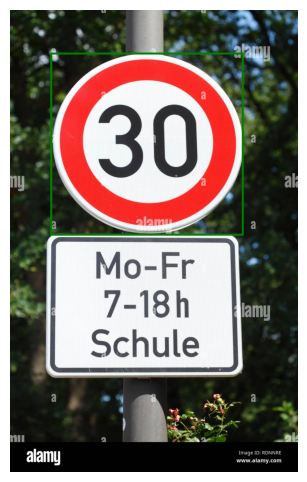

In [ ]:
import cv2
dd=drawr(image,margin,preds)
import matplotlib.pyplot as plt
from PIL import Image

plt.figure(figsize=(6,6))
plt.imshow(dd)
plt.axis("off")
plt.show()


In [ ]:
# Label Overview
classes = { 0:'Speed limit (20km/h)',
            1:'Speed limit (30km/h)',
            2:'Speed limit (50km/h)',
            3:'Speed limit (60km/h)',
            4:'Speed limit (70km/h)',
            5:'Speed limit (80km/h)',
            6:'End of speed limit (80km/h)',
            7:'Speed limit (100km/h)',
            8:'Speed limit (120km/h)',
            9:'No passing',
            10:'No passing veh over 3.5 tons',
            11:'Right-of-way at intersection',
            12:'Priority road',
            13:'Yield',
            14:'Stop',
            15:'No vehicles',
            16:'Veh > 3.5 tons prohibited',
            17:'No entry',
            18:'General caution',
            19:'Dangerous curve left',
            20:'Dangerous curve right',
            21:'Double curve',
            22:'Bumpy road',
            23:'Slippery road',
            24:'Road narrows on the right',
            25:'Road work',
            26:'Traffic signals',
            27:'Pedestrians',
            28:'Children crossing',
            29:'Bicycles crossing',
            30:'Beware of ice/snow',
            31:'Wild animals crossing',
            32:'End speed + passing limits',
            33:'Turn right ahead',
            34:'Turn left ahead',
            35:'Ahead only',
            36:'Go straight or right',
            37:'Go straight or left',
            38:'Keep right',
            39:'Keep left',
            40:'Roundabout mandatory',
            41:'End of no passing',
            42:'End no passing veh > 3.5 tons' }